In [13]:
# %pip install torchsummary

In [14]:
### Basic Imports
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from pathlib import Path
###pytorch
import torch
import torch.nn as nn
from torchvision.transforms import v2
from torchsummary import summary
import glob
import torchmetrics
from torchmetrics.classification import MulticlassAccuracy

In [15]:
data_dir = Path('../../dataset/Rock-Paper-Scissor')
train_data_dir = data_dir/"train"/"rps"
test_data_dir = data_dir/"test"/"rps-test-set"

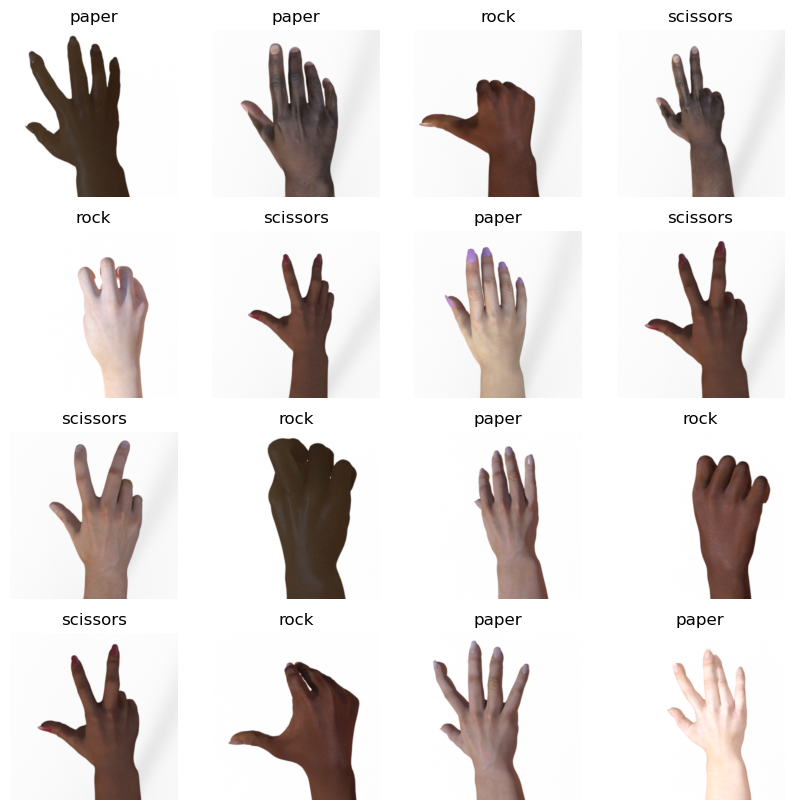

In [16]:
classes = ["rock", "paper", "scissors"]
nrows = 4
ncols = 4

plt.figure(figsize=(10, 10))
for i in range(1, nrows*ncols+1):
    random_class = random.choice(classes)
    random_path = os.path.join(data_dir, "train", "rps", random_class)
    random_image_path = random.choice(glob.glob(os.path.join(random_path, "*.png")))
    img = Image.open(random_image_path)
    plt.subplot(nrows, ncols, i)
    plt.imshow(img)
    plt.title(f'{random_class}')
    plt.axis(False)

In [17]:
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.4),
    v2.RandomRotation(degrees=30),
    v2.Resize((256,256)),
    v2.ToTensor(),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.5]*3, std=[0.5]*3),
    
]
)

test_transform = v2.Compose([
    v2.Resize((256,256)),
    v2.ToTensor(),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.5]*3, std=[0.5]*3), 
]
)

c:\Users\Global Lecturer\miniconda3\envs\mlenv\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [27]:
from data_setup import create_dataloaders
BATCH_SIZE=32

train_loader, test_loader, valid_loader = create_dataloaders(
    train_dir=train_data_dir, test_dir=test_data_dir, batch_size=BATCH_SIZE, 
    train_transform=train_transform, test_transform=test_transform)




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


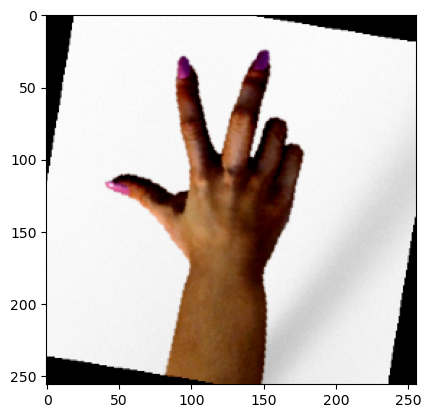

In [19]:
img, label = next(iter(train_loader))
plt.imshow(img[0].permute(1,2, 0))


In [28]:
from model import RPSNet
from train import train_model, eval_model

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = RPSNet(in_channels=3, num_classes=3).to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.001)
metrics = MulticlassAccuracy(num_classes=3).to(device)

results = train_model(
    model=model, epochs=20, train_loader=train_loader, 
    test_loader=test_loader, device=device, metrics=metrics,
    optimizer=optimizer, loss_func=loss_func)

epoch: 1/20 train loss: 1.280717195589331 test loss: 1.1045243775143343 train acc: 0.41626983880996704 test acc: 0.4326939582824707
best model saved
epoch: 2/20 train loss: 0.9211313739607606 test loss: 0.9488714021794936 train acc: 0.5539683103561401 test acc: 0.4592744708061218
best model saved
epoch: 3/20 train loss: 0.7713033670111548 test loss: 0.8758290725595811 train acc: 0.6571428179740906 test acc: 0.5191524028778076
best model saved
epoch: 4/20 train loss: 0.7040659291080281 test loss: 0.7909350044587079 train acc: 0.6952381134033203 test acc: 0.6443644762039185
best model saved
epoch: 5/20 train loss: 0.5915737559523764 test loss: 0.728609702166389 train acc: 0.7710317373275757 test acc: 0.6874097585678101
best model saved
epoch: 6/20 train loss: 0.5431123930442182 test loss: 0.669074007693459 train acc: 0.7801587581634521 test acc: 0.7640058994293213
best model saved
epoch: 7/20 train loss: 0.47121399905108197 test loss: 0.6079501860282001 train acc: 0.8182539939880371 test

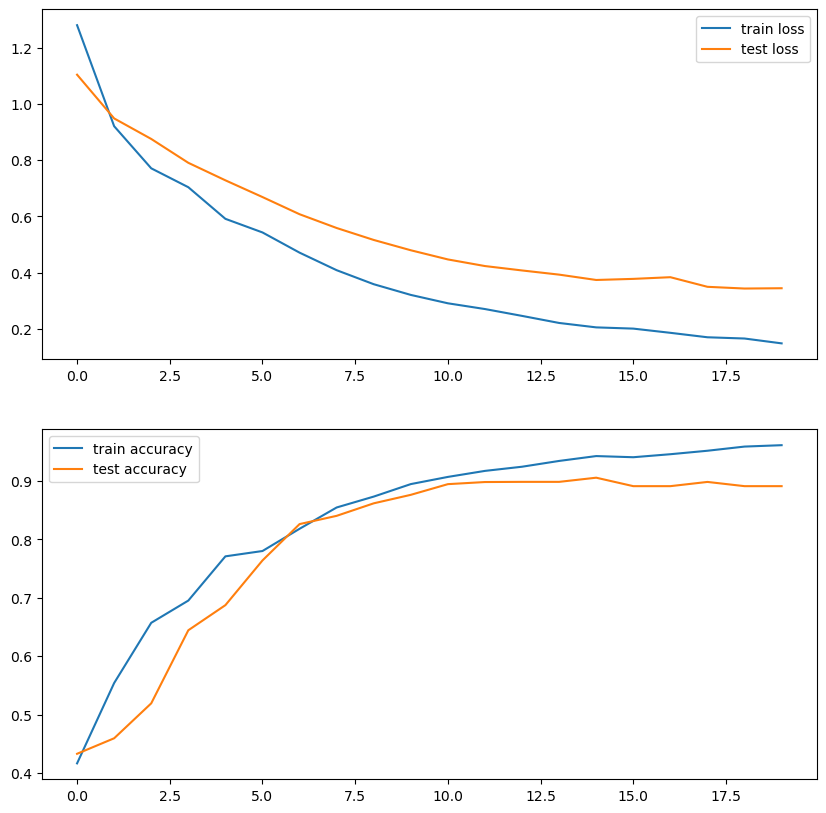

In [22]:
x_range = list(range(len(results["train_loss"])))
fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax= ax.flatten()
ax[0].plot(x_range, results["train_loss"], label="train loss")
ax[0].plot(x_range, results["test_loss"], label="test loss")
ax[0].legend()
ax[1].plot(x_range, results["train_acc"], label="train accuracy")
ax[1].plot(x_range, results["test_acc"], label="test accuracy")
ax[1].legend()

    

In [23]:
valid_loss, valid_acc= eval_model(model=model, dataloader=valid_loader, loss_func=loss_func, metrics=metrics, device=device)


In [24]:
print(f'valid loss: {valid_loss} '
      f'valid acc: {valid_acc}'
      )

valid loss: 0.3234775406973703 valid acc: 0.8854167461395264
